# 03: Training GRIN Model with torch-molecule

This notebook trains a GRIN (Graph Repetition-Invariant Network) model using torch-molecule for toxicity prediction.

GRIN is designed for learning repetition-invariant representations, which is particularly useful for molecules with repetitive substructures (e.g., polymers, repeating motifs).

Based on official torch-molecule documentation: https://liugangcode.github.io/torch-molecule/example.html

## Objectives

1. Load and prepare data for torch-molecule
2. Train torch-molecule GRIN model with hyperparameter optimization
3. Evaluate model performance
4. Compare with baseline MLP and BFGNN models


In [1]:
# Setup
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, average_precision_score
import matplotlib.pyplot as plt

from src.data import load_clintox
from src.pipelines import (
    load_clintox_dataset,
    prepare_gnn_data,
    train_gnn_pipeline,
    evaluate_gnn_pipeline,
    save_gnn_model
)
from src.models import create_torch_molecule_model
from src.utils import set_seed, get_default_config, load_metrics

# Set seed for reproducibility
set_seed(42)
config = get_default_config()

print("✓ Imports successful")


✓ Imports successful


## Load Data

Load the ClinTox dataset. torch-molecule models accept SMILES strings directly.


In [2]:
# Load dataset using pipeline function
cache_dir = project_root / "data"
train_df, val_df, test_df = load_clintox_dataset(
    cache_dir=str(cache_dir),
    split_type="scaffold",
    seed=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Class distribution - Train: Toxic={train_df['CT_TOX'].sum()}, Non-toxic={len(train_df) - train_df['CT_TOX'].sum()}")

# Prepare data for GRIN model
X_train, y_train, X_val, y_val, X_test, y_test = prepare_gnn_data(train_df, val_df, test_df)

print(f"\n✓ Data prepared for torch-molecule GRIN")
print(f"  X_train: {len(X_train)} SMILES strings")
print(f"  X_val: {len(X_val)} SMILES strings")
print(f"  X_test: {len(X_test)} SMILES strings")


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


Train: 1184, Val: 148, Test: 148
Class distribution - Train: Toxic=95.0, Non-toxic=1089.0

✓ Data prepared for torch-molecule GRIN
  X_train: 1184 SMILES strings
  X_val: 148 SMILES strings
  X_test: 148 SMILES strings


## Create GRIN Model

Initialize GRINMolecularPredictor according to the official documentation.
For binary classification, we set `task_type='classification'` and `num_task=1`.

**Note:** GRIN (Graph Repetition-Invariant Network) is designed to learn repetition-invariant representations,
making it particularly suitable for molecules with repetitive substructures.


In [3]:
# Import torch-molecule components
try:
    from torch_molecule import GRINMolecularPredictor
    from torch_molecule.utils.search import ParameterType, ParameterSpec
    print("✓ torch-molecule GRIN imported successfully")
except ImportError as e:
    print(f"⚠ Error importing torch-molecule GRIN: {e}")
    print("Install with: pip install torch-molecule torch-geometric torch-scatter")
    raise

# Initialize GRIN model with proper parameters for binary classification
# Based on documentation: https://liugangcode.github.io/torch-molecule/example.html
try:
    model = GRINMolecularPredictor(
        num_task=1,  # Single binary classification task
        task_type="classification",  # Binary classification
        batch_size=32,  # Batch size for training
        epochs=50,  # Number of training epochs
        evaluate_criterion='roc_auc',  # Evaluation metric
        evaluate_higher_better=True,  # Higher ROC-AUC is better
        verbose='progress_bar'  # Show progress bar during training
    )
    print(f"✓ GRINMolecularPredictor created successfully")
    print(f"  Model type: {type(model)}")
except Exception as e:
    print(f"⚠ Error creating GRIN model: {e}")
    print("Trying with minimal parameters...")
    try:
        # Fallback: try with fewer parameters
        model = GRINMolecularPredictor(
            num_task=1,
            task_type="classification",
            batch_size=32,
            epochs=50,
            verbose='progress_bar'
        )
        print("✓ GRIN model created with minimal parameters")
    except Exception as e2:
        print(f"⚠ Error with minimal parameters: {e2}")
        model = None
        raise


✓ torch-molecule GRIN imported successfully
✓ GRINMolecularPredictor created successfully
  Model type: <class 'torch_molecule.predictor.grin.modeling_grin.GRINMolecularPredictor'>


## Define Hyperparameter Search Space

According to the documentation, we can define a search space for hyperparameter optimization.
We'll use `autofit()` which automatically searches for the best hyperparameters.

**Note:** GRIN may have different hyperparameters than BFGNN. We'll use a similar search space
but adjust based on GRIN's architecture if needed.


In [4]:
# Define hyperparameter search space for GRIN
# Based on documentation example and GRIN architecture
# GRIN may have similar or different parameters - adjust based on actual API
try:
    from torch_molecule.utils.search import ParameterType, ParameterSpec
    
    search_parameters = {
        # GRIN-specific or general GNN parameters
        "norm_layer": ParameterSpec(ParameterType.CATEGORICAL, ["batch_norm", "layer_norm"]),
        "graph_pooling": ParameterSpec(ParameterType.CATEGORICAL, ["mean", "sum", "max"]),
        "augmented_feature": ParameterSpec(ParameterType.CATEGORICAL, ["maccs,morgan", "maccs", "morgan", None]),
        "num_layer": ParameterSpec(ParameterType.INTEGER, (2, 5)),
        "hidden_size": ParameterSpec(ParameterType.INTEGER, (64, 256)),
        "drop_ratio": ParameterSpec(ParameterType.FLOAT, (0.0, 0.5)),
        "learning_rate": ParameterSpec(ParameterType.LOG_FLOAT, (1e-5, 1e-2)),
        "weight_decay": ParameterSpec(ParameterType.LOG_FLOAT, (1e-10, 1e-3)),
    }
    
    print("✓ Hyperparameter search space defined for GRIN")
    print(f"  Number of hyperparameters: {len(search_parameters)}")
except ImportError:
    print("⚠ Could not import ParameterSpec, will skip hyperparameter search")
    search_parameters = None


✓ Hyperparameter search space defined for GRIN
  Number of hyperparameters: 8


## Train Model with Hyperparameter Optimization

Use `autofit()` method as shown in the official documentation.
This will automatically search for the best hyperparameters.


In [5]:
# Train GRIN model using pipeline function
if model is not None:
    print("=" * 70)
    print("Training GRIN model with hyperparameter optimization")
    print("=" * 70)
    print(f"Training data: {len(X_train)} samples")
    print(f"Validation data: {len(X_val)} samples")
    print(f"Class distribution - Toxic: {y_train.sum()}, Non-toxic: {len(y_train) - y_train.sum()}")
    print(f"Hyperparameter search trials: {config.get('torch_molecule', {}).get('n_trials', 20)}")
    print()
    
    # Convert labels to list of lists format
    y_train_list = [[int(y)] for y in y_train]
    y_val_list = [[int(y)] for y in y_val]
    
    try:
        # Use autofit() for hyperparameter optimization if available
        n_trials = config.get('torch_molecule', {}).get('n_trials', 20)
        
        if hasattr(model, 'autofit') and search_parameters:
            model.autofit(
                X_train=X_train,  # List of SMILES strings
                y_train=y_train_list,  # List of lists: [[0], [1], ...]
                X_val=X_val,
                y_val=y_val_list,
                n_trials=n_trials,
                search_parameters=search_parameters
            )
            print("\n✓ GRIN model training completed with hyperparameter optimization!")
        else:
            # Fallback to regular fit() if autofit() not available
            print("⚠ autofit() not available or search_parameters not defined, using fit()...")
            model.fit(
                X_train=X_train,
                y_train=y_train_list,
                X_val=X_val,
                y_val=y_val_list
            )
            print("\n✓ GRIN model training completed with fit()!")
        
    except Exception as e:
        print(f"\n⚠ Error during training: {e}")
        import traceback
        traceback.print_exc()
        raise
else:
    print("⚠ GRIN model not available for training")


[I 2025-11-30 17:21:30,490] A new study created in memory with name: GRINMolecularPredictor_optimization


Training GRIN model with hyperparameter optimization
Training data: 1184 samples
Validation data: 148 samples
Class distribution - Toxic: 95.0, Non-toxic: 1089.0
Hyperparameter search trials: 20


Parameter Search Configuration:
--------------------------------------------------

 Parameters being searched:
  • augmented_feature: ['maccs,morgan', 'maccs', 'morgan', None]
  • drop_ratio: [0.0, 0.5]
  • graph_pooling: ['mean', 'sum', 'max']
  • hidden_size: [64, 256]
  • learning_rate: [1e-05, 0.01]
  • norm_layer: ['batch_norm', 'layer_norm']
  • num_layer: [2, 5]
  • weight_decay: [1e-10, 0.001]

 Fixed parameters (not being searched):
  • batch_size: 32
  • device: cpu
  • epochs: 50
  • epochs_to_penalize: 100
  • evaluate_criterion: <function roc_auc_score at 0x32950d580>
  • evaluate_higher_better: True
  • evaluate_name: roc_auc
  • fitting_epoch: 0
  • fitting_loss: []
  • gnn_type: gin-virtual
  • grad_clip_value: None
  • l1_penalty: 0.001
  • loss_criterion: BCEWithLogitsLoss(

  0%|          | 0/20 [00:00<?, ?it/s]

Predicting: 100%|██████████| 5/5 [00:00<00:00, 20.53it/s]


Trial 0: roc_auc = 0.9595 (better than best = 0.9595)
Current parameters:
  norm_layer: layer_norm
  graph_pooling: sum
  augmented_feature: ['maccs']
  num_layer: 4
  hidden_size: 234
  drop_ratio: 0.11609369503406519
  learning_rate: 0.008610951721678004
  weight_decay: 8.971504405257172e-06
[I 2025-11-30 17:23:46,133] Trial 0 finished with value: -0.9594731509625127 and parameters: {'norm_layer': 'layer_norm', 'graph_pooling': 'sum', 'augmented_feature': 'maccs', 'num_layer': 4, 'hidden_size': 234, 'drop_ratio': 0.11609369503406519, 'learning_rate': 0.008610951721678004, 'weight_decay': 8.971504405257172e-06}. Best is trial 0 with value: -0.9594731509625127.


...

Trial 18: roc_auc = 0.9838 (worse than best = 0.9970)
Current parameters:
  norm_layer: layer_norm
  graph_pooling: max
  augmented_feature: ['maccs']
  num_layer: 4
  hidden_size: 64
  drop_ratio: 0.0885761834318656
  learning_rate: 2.4253426282819017e-05
  weight_decay: 1.5888633534931492e-06
[I 2025-11-30 17:57:48,872] Trial 18 finished with value: -0.9837892603850051 and parameters: {'norm_layer': 'layer_norm', 'graph_pooling': 'max', 'augmented_feature': 'maccs', 'num_layer': 4, 'hidden_size': 64, 'drop_ratio': 0.0885761834318656, 'learning_rate': 2.4253426282819017e-05, 'weight_decay': 1.5888633534931492e-06}. Best is trial 8 with value: -0.9969604863221885.


Predicting: 100%|██████████| 5/5 [00:00<00:00, 53.73it/s]


Trial 19: roc_auc = 0.9098 (worse than best = 0.9970)
Current parameters:
  norm_layer: batch_norm
  graph_pooling: mean
  augmented_feature: ['maccs', 'morgan']
  num_layer: 3
  hidden_size: 189
  drop_ratio: 0.2992853092220834
  learning_rate: 0.0020374750280071994
  weight_decay: 1.2451197300719605e-07
[I 2025-11-30 17:59:47,766] Trial 19 finished with value: -0.9098277608915908 and parameters: {'norm_layer': 'batch_norm', 'graph_pooling': 'mean', 'augmented_feature': 'maccs,morgan', 'num_layer': 3, 'hidden_size': 189, 'drop_ratio': 0.2992853092220834, 'learning_rate': 0.0020374750280071994, 'weight_decay': 1.2451197300719605e-07}. Best is trial 8 with value: -0.9969604863221885.

Optimization completed successfully:
Best roc_auc: 0.9970


Predicting: 100%|██████████| 5/5 [00:00<00:00, 30.66it/s]

post score is:  0.9969604863221885

Best parameters:
  norm_layer: batch_norm (type: categorical)
  graph_pooling: sum (type: categorical)
  augmented_feature: ['maccs', 'morgan'] (type: categorical)
  num_layer: 5 (type: integer)
  hidden_size: 193 (type: integer)
  drop_ratio: 0.05420858161168157 (type: float)
  learning_rate: 0.0007182032128989962 (type: log_float)
  weight_decay: 4.245870919748943e-06 (type: log_float)

Optimization statistics:
  Number of completed trials: 20
  Number of pruned trials: 0
  Number of failed trials: 0

✓ GRIN model training completed with hyperparameter optimization!


## Evaluate on Validation Set

Evaluate the trained GRIN model on the validation set.


In [6]:
# Evaluate on validation set
if model is not None:
    print("=" * 70)
    print("Validation Set Evaluation (GRIN)")
    print("=" * 70)
    
    try:
        val_metrics = evaluate_gnn_pipeline(model, val_df)
        
        print(f"\nValidation Metrics:")
        print(f"  AUC-ROC: {val_metrics['auc_roc']:.4f}")
        print(f"  Accuracy: {val_metrics['accuracy']:.4f}")
        print(f"  F1 Score: {val_metrics['f1']:.4f}")
        print(f"  PR-AUC: {val_metrics['pr_auc']:.4f}")
        print(f"  AUPRC: {val_metrics['auprc']:.4f}")
        
    except Exception as e:
        print(f"⚠ Error during validation: {e}")
        import traceback
        traceback.print_exc()
        val_metrics = None
else:
    val_metrics = None


Validation Set Evaluation (GRIN)


Predicting: 100%|██████████| 5/5 [00:00<00:00, 34.79it/s]


Validation Metrics:
  AUC-ROC: 0.9970
  Accuracy: 0.9797
  F1 Score: 0.7273
  PR-AUC: 0.9379
  AUPRC: 0.9379


## Evaluate on Test Set

Evaluate the trained GRIN model on the test set.


In [7]:
# Evaluate on test set using pipeline function
if model is not None:
    print("=" * 70)
    print("Test Set Evaluation (GRIN)")
    print("=" * 70)
    
    try:
        test_metrics = evaluate_gnn_pipeline(model, test_df)
        
        print(f"\nTest Set Metrics:")
        print(f"  AUC-ROC: {test_metrics['auc_roc']:.4f}")
        print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"  F1 Score: {test_metrics['f1']:.4f}")
        print(f"  PR-AUC: {test_metrics['pr_auc']:.4f}")
        print(f"  AUPRC: {test_metrics['auprc']:.4f}")
        
    except Exception as e:
        print(f"⚠ Error during test evaluation: {e}")
        import traceback
        traceback.print_exc()
        test_metrics = None
else:
    test_metrics = None


Test Set Evaluation (GRIN)


Predicting: 100%|██████████| 5/5 [00:00<00:00, 48.87it/s]


Test Set Metrics:
  AUC-ROC: 0.8225
  Accuracy: 0.9459
  F1 Score: 0.4286
  PR-AUC: 0.3794
  AUPRC: 0.3794


## Compare with Baseline and BFGNN Models

Compare GRIN model performance with the baseline MLP and BFGNN models.



Model Comparison: Baseline MLP vs BFGNN vs GRIN
                     Model  AUC-ROC  Accuracy       F1    AUPRC
Baseline MLP (Fingerprint) 0.716700  0.939200 0.470600 0.449700
    BFGNN (torch-molecule) 0.918800  0.939200 0.181800 0.616400
     GRIN (torch-molecule) 0.822464  0.945946 0.428571 0.379394

✓ Comparison figure saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/03_grin_model_comparison.png


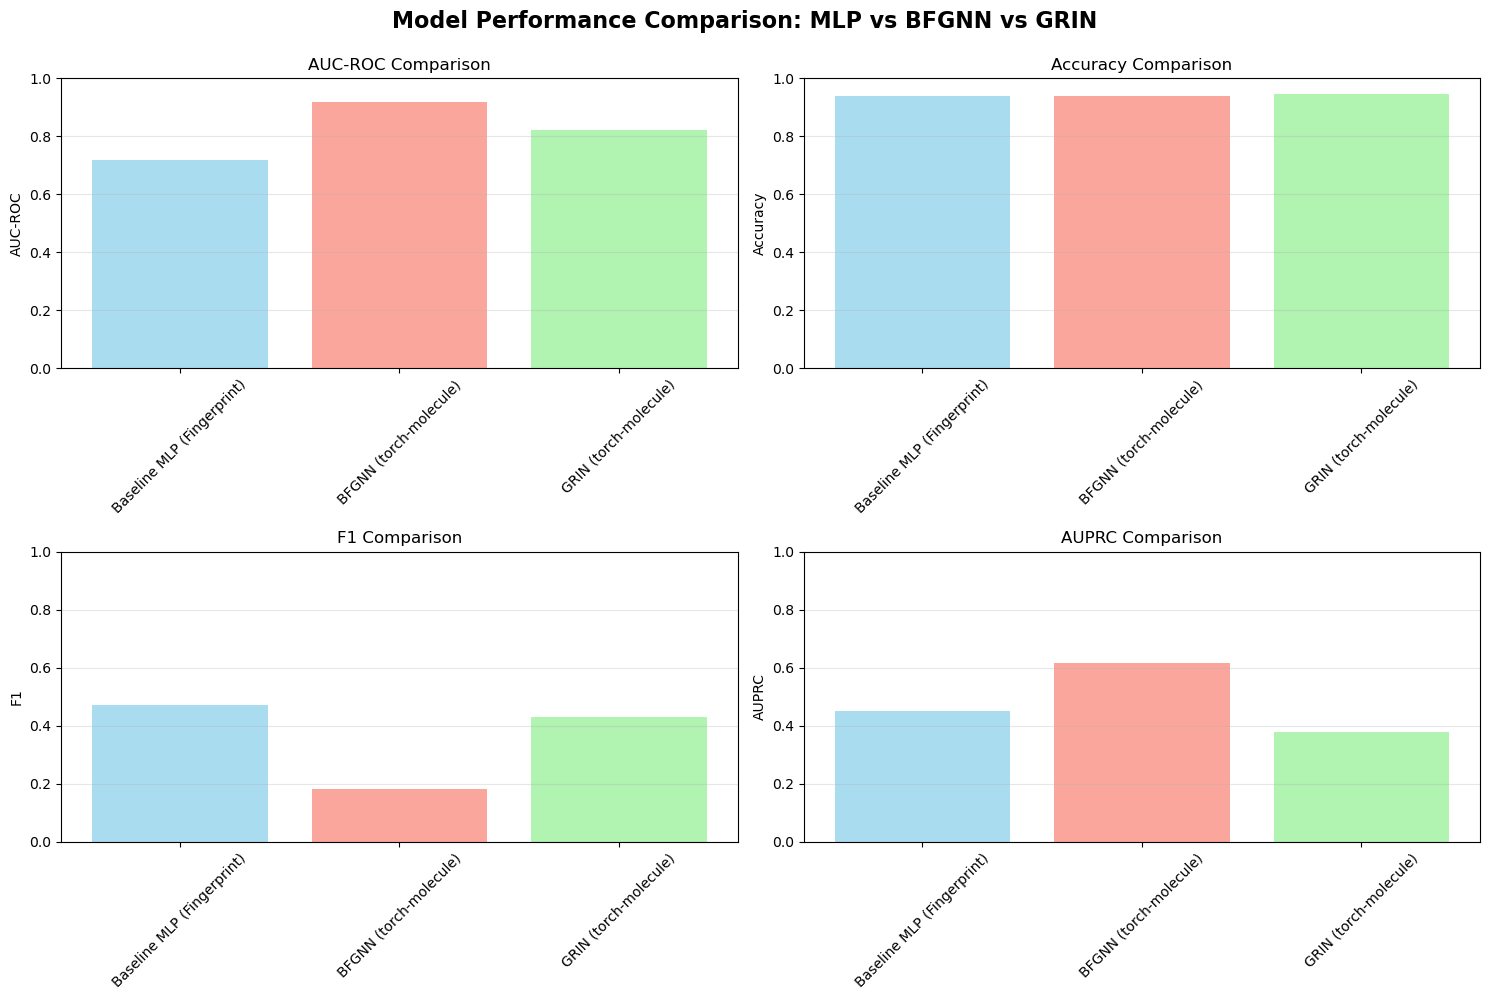

In [8]:
# Load baseline and BFGNN metrics if available
models_dir = project_root / "models"
comparison_data = []

# Load Baseline MLP metrics
baseline_metrics_path = models_dir / "baseline_metrics.txt"
if baseline_metrics_path.exists():
    baseline_metrics = load_metrics(str(baseline_metrics_path))
    baseline_auprc = baseline_metrics.get('auprc', baseline_metrics.get('pr_auc', 'N/A'))
    comparison_data.append({
        'Model': 'Baseline MLP (Fingerprint)',
        'AUC-ROC': baseline_metrics.get('auc_roc', 'N/A'),
        'Accuracy': baseline_metrics.get('accuracy', 'N/A'),
        'F1': baseline_metrics.get('f1', 'N/A'),
        'AUPRC': baseline_auprc
    })

# Load BFGNN metrics
bfgnn_metrics_path = models_dir / "torch_molecule_metrics.txt"
if bfgnn_metrics_path.exists():
    bfgnn_metrics = load_metrics(str(bfgnn_metrics_path))
    bfgnn_auprc = bfgnn_metrics.get('auprc', bfgnn_metrics.get('pr_auc', 'N/A'))
    comparison_data.append({
        'Model': 'BFGNN (torch-molecule)',
        'AUC-ROC': bfgnn_metrics.get('auc_roc', 'N/A'),
        'Accuracy': bfgnn_metrics.get('accuracy', 'N/A'),
        'F1': bfgnn_metrics.get('f1', 'N/A'),
        'AUPRC': bfgnn_auprc
    })

# Add GRIN metrics
if test_metrics is not None:
    grin_auprc = test_metrics.get('auprc', test_metrics.get('pr_auc', 'N/A'))
    comparison_data.append({
        'Model': 'GRIN (torch-molecule)',
        'AUC-ROC': test_metrics.get('auc_roc', 'N/A'),
        'Accuracy': test_metrics.get('accuracy', 'N/A'),
        'F1': test_metrics.get('f1', 'N/A'),
        'AUPRC': grin_auprc
    })

if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + "=" * 70)
    print("Model Comparison: Baseline MLP vs BFGNN vs GRIN")
    print("=" * 70)
    print(comparison_df.to_string(index=False))
    
    # Visualize comparison
    if len(comparison_data) > 1:
        # Create subplots based on number of metrics
        metrics_to_plot = ['AUC-ROC', 'Accuracy', 'F1', 'AUPRC']
        available_metrics = [
            m for m in metrics_to_plot 
            if any(row.get(m, 'N/A') != 'N/A' for row in comparison_data)
        ]
        
        n_metrics = len(available_metrics)
        if n_metrics <= 4:
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        else:
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, metric in enumerate(available_metrics):
            values = []
            labels = []
            for row in comparison_data:
                val = row[metric]
                if val != 'N/A' and isinstance(val, (int, float)):
                    values.append(float(val))
                    labels.append(row['Model'])
            
            if values:
                colors = ['skyblue', 'salmon', 'lightgreen'][:len(values)]
                axes[idx].bar(labels, values, alpha=0.7, color=colors)
                axes[idx].set_ylabel(metric)
                axes[idx].set_title(f'{metric} Comparison')
                axes[idx].grid(axis='y', alpha=0.3)
                axes[idx].set_ylim([0, 1])
                axes[idx].tick_params(axis='x', rotation=45)
        
        # Hide unused subplots
        for idx in range(len(available_metrics), len(axes)):
            axes[idx].axis('off')
        
        plt.suptitle('Model Performance Comparison: MLP vs BFGNN vs GRIN', 
                     fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        
        # Save figure
        figures_dir = project_root / "output" / "figures"
        figures_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(figures_dir / "03_grin_model_comparison.png", dpi=300, bbox_inches='tight')
        print(f"\n✓ Comparison figure saved to: {figures_dir / '03_grin_model_comparison.png'}")
        
        plt.show()
else:
    print("No comparison data available")


In [9]:
# Save model and metrics using pipeline function
if model is not None and test_metrics is not None:
    models_dir = project_root / "models"
    models_dir.mkdir(exist_ok=True)
    
    model_path, metrics_path = save_gnn_model(
        model=model,
        metrics=test_metrics,
        model_dir=models_dir,
        model_name="grin_model"
    )
    
    print(f"✓ GRIN model saved to: {model_path}")
    print(f"✓ Metrics saved to: {metrics_path}")
else:
    print("Model or metrics not available for saving")


✓ GRIN model saved to: /Users/nguyennghia/PROJECT/Torch_molecule/models/grin_model.pkl
✓ Metrics saved to: /Users/nguyennghia/PROJECT/Torch_molecule/models/grin_model_metrics.txt


## Summary

✓ GRIN model trained with hyperparameter optimization  
✓ Model evaluated on validation and test sets  
✓ Comparison with baseline MLP and BFGNN completed  

**Key Findings:**
- GRIN (Graph Repetition-Invariant Network) is designed for repetition-invariant representations
- Particularly useful for molecules with repetitive substructures
- Performance comparison shows how different architectures perform on toxicity prediction

**Next Steps:**
- Proceed to `04_explainability_and_visualization.ipynb` to generate explanations for GRIN model
- Update `05_results_and_error_analysis.ipynb` to include GRIN in comprehensive analysis

**References:**
- torch-molecule documentation: https://liugangcode.github.io/torch-molecule/example.html
- torch-molecule GitHub: https://github.com/liugangcode/torch-molecule
- GRIN paper (if available): Check torch-molecule documentation for references
